In [3]:
from utils import DQN, ReplayBuffer, greedy_action, epsilon_greedy, update_target, loss

import torch # ML library 
from torch import nn
import torch.nn.functional as F
import torch.optim as optim
import math
import numpy as np

import gym # provides various RL environments
import matplotlib.pyplot as plt

import os
import fnmatch
import logging 
import pandas as pd

In [11]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
# lr = 0.01
num_episodes = 300
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.01
initial_alpha = 1

Epsilon


Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 

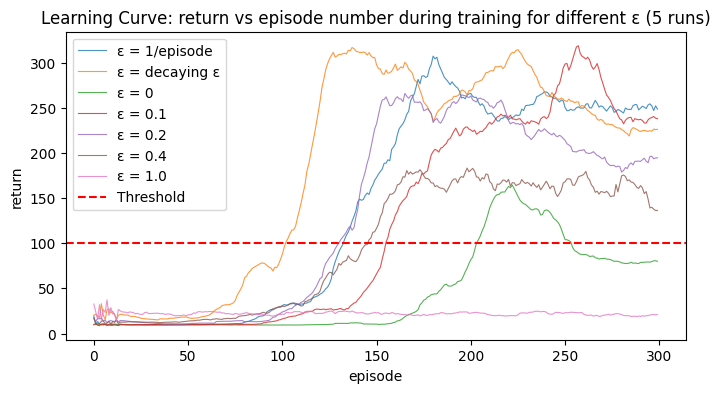

In [12]:
epsilon_values = ['1/episode', 'decaying ε', '0', '0.1', '0.2', '0.4', '1.0']  # Define the epsilon values
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n
plt.figure(figsize=(8, 4)) # width:height

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value

    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 
        lr = 0.01

        optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        # lr = initial_alpha

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            # lr = max(0.955*lr, min_alpha)
            # optimizer = optim.SGD(policy_net.parameters(), lr)

            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0

            # Modify the EPSILON based on epsilon_value
            
            match (epsilon_value):
                case '1/episode':
                    EPSILON = max(1 / (i_episode + 1), min_epsilon)
                case 'decaying ε':
                    EPSILON = max(EPSILON*decay_rate, min_epsilon)
                case '0':
                    EPSILON = 0
                case '0.1':
                    EPSILON = 0.1
                case '0.2':
                    EPSILON = 0.2
                case '0.4':
                    EPSILON = 0.4
                case '1.0':
                    EPSILON = 1

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    means = [*means[:14], *moving_average(means, n=15)]
    stds = results.float().std(0)

    plt.plot(torch.arange(num_episodes), means, label=f"ε = {epsilon_value}", linewidth = 0.8, alpha = 0.8)


plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left')
plt.title('Learning Curve: return vs episode number during training for different ε (5 runs)') # NUMBER OF RUNS
plt.show()

In [38]:
plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/MA different epsilon.svg")

<Figure size 640x480 with 0 Axes>

Alpha

In [17]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
num_episodes = 300
batch_size = 128
buffer_size = 100000
update_period = 15
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.01

Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 

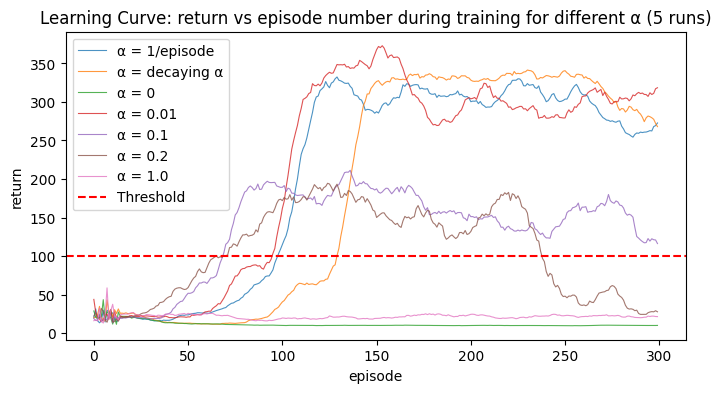

In [18]:
epsilon_values = ['1/episode', 'decaying α', '0', '0.01', '0.1', '0.2', '1.0']  # Define the alpha values
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n
plt.figure(figsize=(8, 4)) # width:height

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value

    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 

        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            match (epsilon_value):
                case '1/episode': 
                    lr = max(1 / (i_episode + 1), min_alpha)
                case 'decaying α':
                    lr = max(lr*0.955, min_alpha)
                case '0':
                    lr = 0
                case '0.01':
                    lr = 0.01
                case '0.1':
                    lr = 0.1
                case '0.2':
                    lr = 0.2
                case '1.0':
                    lr = 1
            
            optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
            
            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0          
            
            # Decaying epsilon 
            EPSILON = max(min_epsilon, EPSILON*decay_rate) 

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    means = [*means[:14], *moving_average(means, n=15)]
    stds = results.float().std(0)

    plt.plot(torch.arange(num_episodes), means, label=f"α = {epsilon_value}", linewidth = 0.8, alpha = 0.8)


plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.title('Learning Curve: return vs episode number during training for different α (5 runs)') # NUMBER OF RUNS
plt.show()

In [39]:
plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/MA different alpha.svg")

<Figure size 640x480 with 0 Axes>

In [17]:
# Saving the trained model
torch.save(policy_net.state_dict(), 'policy_net.pth')

Update period

In [34]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
num_episodes = 300
batch_size = 128
buffer_size = 100000
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.01
initial_alpha = 1

Starting run 1 of 3


C:\Users\yhara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 /

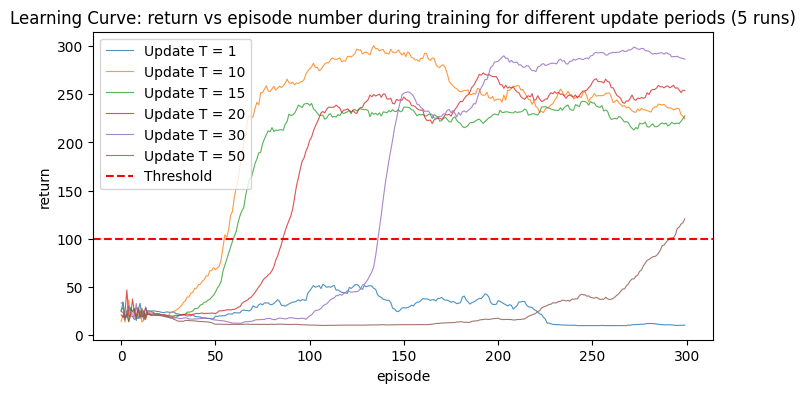

In [35]:
epsilon_values = ['1', '10', '15', '20', '30', '50']  # Define the update period
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n

plt.figure(figsize=(8, 4)) # width:height

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value

    match (epsilon_value):
                case '1':
                    update_period = 1
                case '10':
                    update_period = 10
                case '15':
                    update_period = 15
                case '20':
                    update_period = 20
                case '30':
                    update_period = 30
                case '50':
                    update_period = 50

    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 

        lr = initial_alpha

        # optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            lr = max(lr*0.955, min_alpha)
            optimizer = optim.SGD(policy_net.parameters(), lr)
            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0          
            
            # Decaying epsilon 
            EPSILON = max(min_epsilon, EPSILON*decay_rate)

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    means = [*means[:14], *moving_average(means, n=15)]
    stds = results.float().std(0)

    plt.plot(torch.arange(num_episodes), means, label=f"Update T = {epsilon_value}", linewidth = 0.8, alpha = 0.8)


plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.title('Learning Curve: return vs episode number during training for different update periods (5 runs)') # NUMBER OF RUNS
plt.show()

In [40]:
plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/MA different update periods.svg")

<Figure size 640x480 with 0 Axes>

Batch size to see if variance is smaller for larger batches

In [57]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
num_episodes = 300
buffer_size = 100000
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
min_alpha = 0.01
initial_alpha = 1
update_period = 15

Starting run 1 of 3


C:\Users\yhara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 /

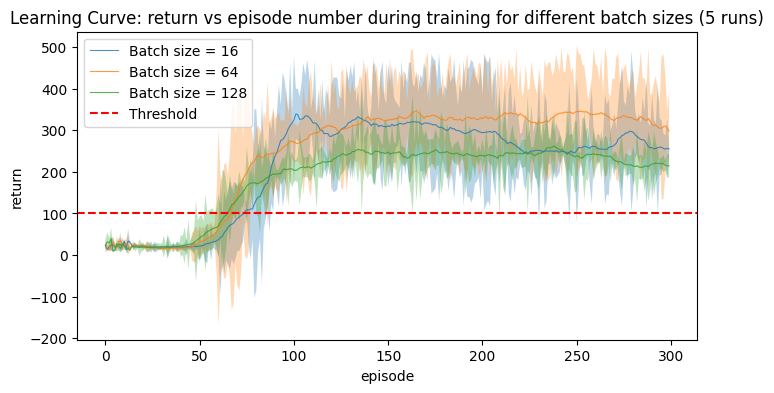

In [58]:
epsilon_values = ['16', '64', '128']  # Define the update period
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n

plt.figure(figsize=(8, 4)) # width:height

mean_std_values = []

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value

    match (epsilon_value):
                case '16':
                    batch_size = 16
                case '64':
                    batch_size = 64
                case '128':
                    batch_size = 128


    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 

        lr = initial_alpha

        # optimizer = optim.SGD(policy_net.parameters(), lr) # stochastic gradient descent, learning rate
        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            lr = max(lr*0.955, min_alpha)
            optimizer = optim.SGD(policy_net.parameters(), lr)
            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0          
            
            # Decaying epsilon 
            EPSILON = max(min_epsilon, EPSILON*decay_rate)

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    # means = [*means[:14], *moving_average(means, n=15)]
    means = torch.cat([means[:14], torch.tensor(moving_average(means.numpy(), n=15))])  # Convert to tensor and concatenate
    stds = results.float().std(0)

    mean_std = stds.mean().item()  # Calculate the mean of standard deviations for the current epsilon_value
    mean_std_values.append(mean_std)  # Store the mean std deviation for each epsilon_value

    plt.plot(torch.arange(num_episodes), means, label=f"Batch size = {epsilon_value}", linewidth = 0.8, alpha = 0.8)
    # plt.fill_between(torch.arange(num_episodes), means - stds, means + stds, alpha=0.3)
    plt.fill_between(torch.arange(num_episodes), (means - stds).numpy(), (means + stds).numpy(), alpha=0.3)

plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.title('Learning Curve: return vs episode number during training for different batch sizes (5 runs)') # NUMBER OF RUNS
plt.show()

In [56]:
print(mean_std_values)

[78.87645721435547, 75.09211730957031, 107.41812133789062]


Optimisers

In [1]:
# Parameters 
NUM_RUNS = 3
# placeholder value - you should implement your own exploration schedule
num_episodes = 300
batch_size = 128
buffer_size = 100000
decay_rate = 0.98 # for epsilon
initial_epsilon = 1
min_epsilon = 0.1
initial_alpha = 1
min_alpha = 0.01
update_period = 15

Starting run 1 of 3


C:\Users\yhara\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.11_qbz5n2kfra8p0\LocalCache\local-packages\Python311\site-packages\gym\utils\passive_env_checker.py:233: DeprecationWarning: `np.bool8` is a deprecated alias for `np.bool_`.  (Deprecated NumPy 1.24)
  if not isinstance(terminated, (bool, np.bool8)):


episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 3 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Complete
Starting run 1 of 3
episode  50 / 300
episode  100 / 300
episode  150 / 300
episode  200 / 300
episode  250 / 300
episode  300 / 300
Starting run 2 of 3
episode  50 / 300
episode  100 / 300
episode  150 /

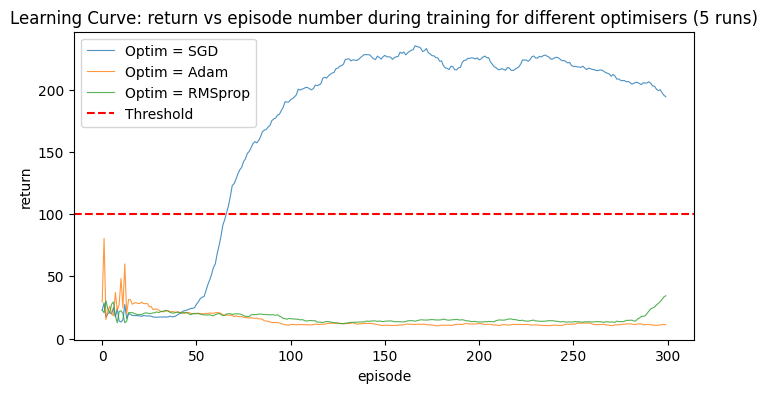

In [4]:
epsilon_values = ['SGD', 'Adam', 'RMSprop']  # Define the update period
env = gym.make('CartPole-v1') 

def moving_average(a, n=3):
    ret = np.cumsum(a, dtype=float)
    ret[n:] = ret[n:] - ret[:-n]
    return ret[n - 1:]/n

plt.figure(figsize=(8, 4)) # width:height

for epsilon_value in epsilon_values:
    runs_results = []  # Reset runs_results for each epsilon value


    for run in range(NUM_RUNS):
        print(f"Starting run {run+1} of {NUM_RUNS}")

        architecture = [4, 50, 50, 2]
        policy_net = DQN(architecture) # input = 4 and output = 2 (0 or 1) 
        target_net = DQN(architecture)
        update_target(target_net, policy_net)
        target_net.eval()
        
        # Layer size
        layer_size = architecture[1] 
        
        # optimizer = optim.Adam(policy_net.parameters(), lr=learning_rate)
        memory = ReplayBuffer(buffer_size) # 1 originally 

        steps_done = 0

        episode_durations = []

        lr = initial_alpha

        EPSILON = initial_epsilon  # Reset EPSILON for each epsilon value
        for i_episode in range(num_episodes):
            lr = max(min_alpha, lr*0.955)
            
            match (epsilon_value):
                case 'SGD':
                    optimizer = optim.SGD(policy_net.parameters(), lr)
                case 'Adam':
                    optimizer = optim.Adam(policy_net.parameters(), lr)
                case 'RMSprop':
                    optimizer = optim.RMSprop(policy_net.parameters(), lr)


            if (i_episode+1) % 50 == 0:
                print("episode ", i_episode+1, "/", 300)

            observation, info = env.reset()
            state = torch.tensor(observation).float()

            done = False
            terminated = False
            t = 0          
            
            # Decaying epsilon 
            EPSILON = max(min_epsilon, EPSILON*decay_rate)

            # Rest of your code remains unchanged
            while not (done or terminated):

            # Select and perform an action
                action = epsilon_greedy(EPSILON, policy_net, state)
                # action = greedy_action(policy_net, state) # can try without epsilon greedy 

                # reward is a scalar, [reward] creates a one-element list, which is converted into a tensor
                observation, reward, done, terminated, info = env.step(action)
                reward = torch.tensor([reward])
                action = torch.tensor([action])
                next_state = torch.tensor(observation).reshape(-1).float()

                # store in replay buffer
                memory.push([state, action, next_state, reward, torch.tensor([done])])

                # Move to the next state
                state = next_state

                # Perform one step of the optimization (on the policy network)
                if not len(memory.buffer) < batch_size: # only proceed if enough data in buffer 
                    transitions = memory.sample(batch_size) # sample one transition from buffer
                    state_batch, action_batch, nextstate_batch, reward_batch, dones = (torch.stack(x) for x in zip(*transitions)) # and unpack
                    # Compute loss
                    mse_loss = loss(policy_net, target_net, state_batch, action_batch, reward_batch, nextstate_batch, dones)
                    # Optimize the model
                    optimizer.zero_grad() # from optimizer, reset gradient to prep for new step 
                    mse_loss.backward() # store gradient of the loss wrt each para 
                    optimizer.step() # carry out gradient dedscent step & update of para 
            
            
                if done or terminated:
                    episode_durations.append(t + 1)
                t += 1
            if i_episode % update_period == 0: 
                update_target(target_net, policy_net)

        runs_results.append(episode_durations)
    print('Complete')

    # Plotting learning curve for each epsilon value
    results = torch.tensor(runs_results)

    means = results.float().mean(0)
    means = [*means[:14], *moving_average(means, n=15)]
    stds = results.float().std(0)

    plt.plot(torch.arange(num_episodes), means, label=f"Optim = {epsilon_value}", linewidth = 0.8, alpha = 0.8)


plt.ylabel("return")
plt.xlabel("episode")
# plt.fill_between(np.arange(num_episodes), means, means + stds, alpha=0.3, color='b')
# plt.fill_between(np.arange(num_episodes), means, means - stds, alpha=0.3, color='b')
plt.axhline(y=100, color='r', linestyle='--', label='Threshold')
plt.legend(loc='upper left') 
plt.title('Learning Curve: return vs episode number during training for different optimisers (5 runs)') # NUMBER OF RUNS
plt.show()

In [5]:
plt.savefig("C:/Users/yhara/OneDrive - Imperial College London/YEAR 4/RL/MA different optimisers.svg")

<Figure size 640x480 with 0 Axes>

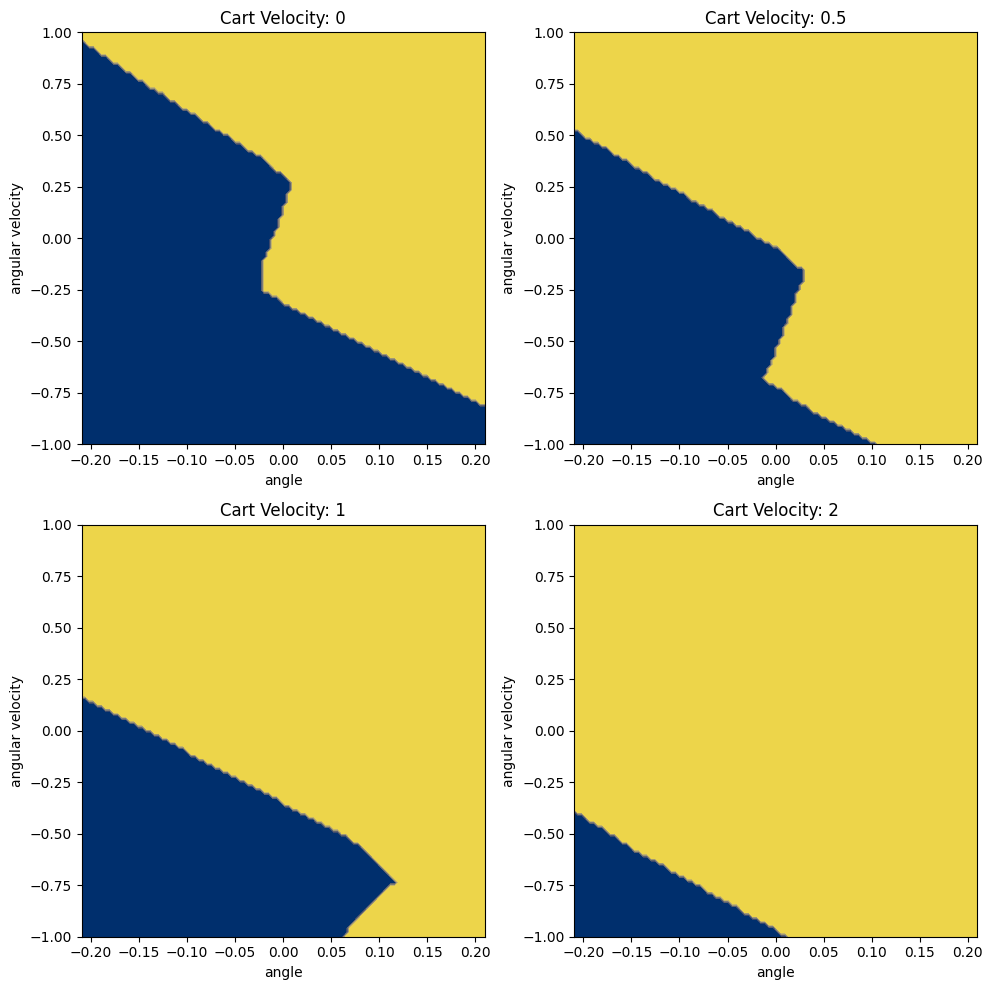

In [16]:
# Visualising the greedy Q-values for a stationary cart in the middle of the track
# 2D plot showing policy as a function of pole angle and angular velocity (omega)

# This plots the policy and Q values according to the network currently
# stored in the variable "policy_net"

# All visualisations provided here are placeholders and you can modify these plots

# Make sure to include appropriate labels and/or legends when presenting your plot

# policy_net = DQN([4,2])   # randomly initialised, replace with your trained DQN
q = False    # whether q values or greedy policy is visualised

angle_range = .2095 # you may modify this range
omega_range = 1     # you may modify this range

angle_samples = 100
omega_samples = 100
angles = torch.linspace(angle_range, -angle_range, angle_samples) # 100 samples between -0.2095 and +0.2095 
omegas = torch.linspace(-omega_range, omega_range, omega_samples)

velocities = [0, 0.5, 1, 2]

fig, axs = plt.subplots(2, 2, figsize=(10, 10))

for idx, velocity in enumerate(velocities):
    greedy_q_array = torch.zeros((angle_samples, omega_samples))
    policy_array = torch.zeros((angle_samples, omega_samples))

    for i, angle in enumerate(angles):
        for j, omega in enumerate(omegas):
            state = torch.tensor([0, velocity, angle, omega])
            with torch.no_grad():
                q_vals = policy_net(state)
                greedy_action = q_vals.argmax()
                greedy_q_array[i, j] = q_vals[greedy_action]
                policy_array[i, j] = greedy_action
    if q:
        axs[idx // 2, idx % 2].contourf(angles, omegas, greedy_q_array.T, cmap='cividis', levels=100)
    else:
        axs[idx // 2, idx % 2].contourf(angles, omegas, policy_array.T, cmap='cividis')
    axs[idx // 2, idx % 2].set_xlabel("angle")
    axs[idx // 2, idx % 2].set_ylabel("angular velocity")
    axs[idx // 2, idx % 2].set_title(f"Cart Velocity: {velocity}")

plt.tight_layout()
plt.show()